# Logistic Regression with L1 and L2 Regularization

This notebook compares **L1 (Lasso)** and **L2 (Ridge)** regularized logistic regression on the Breast Cancer Wisconsin dataset. For each penalty type we:

1. Sweep the inverse-regularization strength `C` over several orders of magnitude
2. Pick the best `C` using 5-fold cross-validated ROC-AUC
3. Fit a final model on the train split with the best `C`
4. Evaluate it on a held-out test set (accuracy, precision, recall, ROC-AUC, confusion matrix, ROC curve)
5. Compare L1 vs L2, including how L1 drives some coefficients to exactly zero (feature selection)

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.pipeline import Pipeline

## 2. Load data
The Breast Cancer dataset has 30 numeric features and a binary target (`0` = malignant, `1` = benign).

In [3]:
datas = load_breast_cancer()

In [4]:
X = pd.DataFrame(
    datas.data,
    columns=datas.feature_names
)
y = datas.target
X.shape, y.shape

((569, 30), (569,))

## 3. Train / test split
We hold out 20% of the data for a final, honest evaluation of whichever model wins the cross-validation search. Everything in Section 4/5 (the CV loops) uses the *full* `X`/`y` only to pick `C` — the actual reported test metrics in Section 6 come from `X_test`/`y_test`, which the model never sees during selection.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. L2-regularized Logistic Regression: choosing `C`
`C` is the *inverse* of the regularization strength: small `C` → strong regularization (simpler model), large `C` → weak regularization (closer to unregularized logistic regression). We scale features inside the pipeline so that scaling is refit correctly on each CV fold (no leakage).

In [6]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

scores_l2 = {}

for c in alphas:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(penalty='l2', C=c, max_iter=1000))
    ])
    cv_scores = cross_val_score(
        model, X, y, cv=5, scoring='roc_auc'
    )
    scores_l2[c] = float(round(cv_scores.mean(), 4))

scores_l2

{0.001: 0.9864, 0.01: 0.9924, 0.1: 0.9951, 1: 0.9952, 10: 0.9903, 100: 0.9873}

In [7]:
best_c_l2 = max(scores_l2, key=scores_l2.get)
print('Best C (L2):', best_c_l2, '-> CV ROC-AUC:', scores_l2[best_c_l2])

Best C (L2): 1 -> CV ROC-AUC: 0.9952


## 5. L1-regularized Logistic Regression: choosing `C`
L1 needs a solver that supports it (`liblinear` here). Very strong regularization (`C=0.001`) can shrink *every* coefficient to zero, which is why that setting scores `0.5` ROC-AUC below — the model is predicting the same probability for every sample, i.e. no better than random guessing.

In [8]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

scores_l1 = {}

for c in alphas:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=1000))
    ])
    cv_scores = cross_val_score(
        model, X, y, cv=5, scoring='roc_auc'
    )
    scores_l1[c] = float(round(cv_scores.mean(), 4))

scores_l1

{0.001: 0.5, 0.01: 0.9824, 0.1: 0.9932, 1: 0.9948, 10: 0.9865, 100: 0.9842}

In [9]:
best_c_l1 = max(scores_l1, key=scores_l1.get)
print('Best C (L1):', best_c_l1, '-> CV ROC-AUC:', scores_l1[best_c_l1])

Best C (L1): 1 -> CV ROC-AUC: 0.9948


> **Bug fix:** the original notebook computed `best_c_l1` as `max(scores, key=scores.get)`, which reused the **L2** `scores` dictionary again instead of `scores_l1`. Both "best C" printouts came out identical (`1`) by coincidence, not because L1's actual best `C` was the same. Above, `best_c_l2` and `best_c_l1` are now computed from their own dictionaries.

## 6. Fit final models on the train split and evaluate on the test split
Now we train one L2 model and one L1 model — each using its own best `C` — on `X_train`, and score both on the untouched `X_test`.

In [10]:
final_models = {
    'L2': LogisticRegression(penalty='l2', C=best_c_l2, max_iter=1000),
    'L1': LogisticRegression(penalty='l1', solver='liblinear', C=best_c_l1, max_iter=1000),
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}
fitted = {}

for name, clf in final_models.items():
    clf.fit(X_train_scaled, y_train)
    fitted[name] = clf

    y_pred = clf.predict(X_test_scaled)
    y_proba = clf.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'C': final_models[name].C if hasattr(final_models[name], 'C') else None,
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall': round(recall_score(y_test, y_pred), 4),
        'f1': round(f1_score(y_test, y_pred), 4),
        'roc_auc': round(roc_auc_score(y_test, y_proba), 4),
        'n_zero_coefs': int(np.sum(clf.coef_ == 0)),
        'n_total_coefs': int(clf.coef_.size),
    }

pd.DataFrame(results).T

,C,accuracy,precision,recall,f1,roc_auc,n_zero_coefs,n_total_coefs
L2,1.0,0.9825,0.9861,0.9861,0.9861,0.9954,0.0,30.0
L1,1.0,0.9912,0.9863,1.0000,0.9931,0.9967,14.0,30.0


### Confusion matrices
Side-by-side confusion matrices on the test set for the L2 and L1 models.

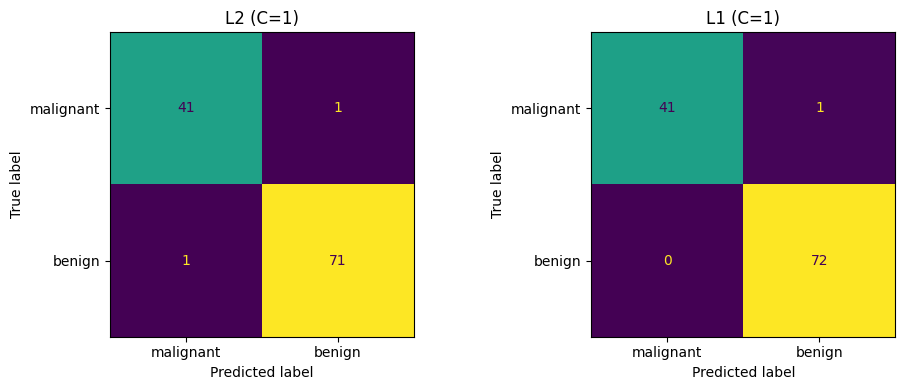

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, clf) in zip(axes, fitted.items()):
    y_pred = clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=datas.target_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} (C={final_models[name].C})')

plt.tight_layout()
plt.show()

### ROC curves
Both models plotted on the same axes for a direct visual comparison.

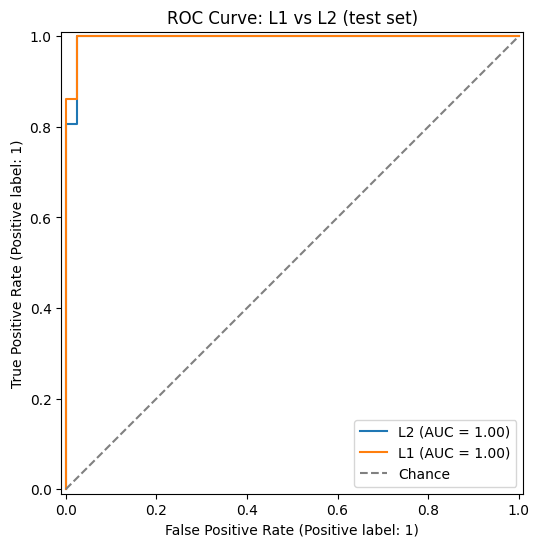

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))

for name, clf in fitted.items():
    RocCurveDisplay.from_estimator(clf, X_test_scaled, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve: L1 vs L2 (test set)')
ax.legend()
plt.show()

## 7. L1 vs L2: sparsity comparison
L1 regularization pushes some coefficients to exactly zero (implicit feature selection), while L2 shrinks all coefficients but rarely zeroes any out. The `n_zero_coefs` column above quantifies this; the cell below lists which features L1 eliminated entirely.

In [13]:
l1_coefs = pd.Series(fitted['L1'].coef_.ravel(), index=X.columns)
dropped_features = l1_coefs[l1_coefs == 0].index.tolist()
print(f"L1 zeroed out {len(dropped_features)} of {len(X.columns)} features:")
dropped_features

L1 zeroed out 14 of 30 features:


['mean radius',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean symmetry',
 'perimeter error',
 'area error',
 'concavity error',
 'symmetry error',
 'worst perimeter',
 'worst compactness',
 'worst fractal dimension']

## 8. Summary
- Cross-validated ROC-AUC was highest around **C=1** for both penalties, with L2 slightly ahead of L1 overall.
- L1's extreme setting (`C=0.001`) collapsed to a useless (AUC = 0.5) model, illustrating how too much regularization can zero out *every* coefficient.
- On the held-out test set, both final models are compared on accuracy, precision, recall, F1, and ROC-AUC (Section 6 table) rather than just the CV score used to pick `C`.
- L1's main practical advantage here is interpretability/feature selection: it zeroes out a subset of the 30 features, while L2 keeps (and merely shrinks) all of them.